<a href="https://colab.research.google.com/github/MinThwMN/Retail-Store-Inventory-Forecasting/blob/main/Raindom_Forest(PTDL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================================================
# 1. Import thư viện +Load dữ liệu
# ================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
# ================================================================
# Load dữ liệu
# ================================================================
# Đọc file CSV từ Drive
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/retail_store_inventory.csv'
df = pd.read_csv(file_path, parse_dates=['Date'])
df = df.sort_values('Date') # Sắp xếp dữ liệu theo thời gian


# Tạo thư mục nếu chưa tồn tại
os.makedirs("/content/drive/MyDrive/Colab Notebooks/models(1)", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Colab Notebooks/preds(1)", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Colab Notebooks/plots(1)", exist_ok=True)

# Xóa duplicate
df = df.drop_duplicates()

df.head()


Mounted at /content/drive


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
72,2022-01-01,S004,P0013,Furniture,East,191,56,65,54.47,61.81,0,Sunny,0,63.92,Autumn
71,2022-01-01,S004,P0012,Electronics,North,349,9,165,0.95,14.25,5,Rainy,1,18.56,Spring
70,2022-01-01,S004,P0011,Electronics,West,205,46,27,46.65,54.84,0,Sunny,1,57.76,Spring
69,2022-01-01,S004,P0010,Groceries,East,447,104,96,115.03,33.48,15,Cloudy,0,37.15,Summer


In [ ]:

# ===============================
# 2. Chuẩn hóa tên cột
# ===============================
df.columns = df.columns.str.strip().str.replace(" ", "_")
df['Date'] = pd.to_datetime(df['Date'])
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Store_ID"] = le.fit_transform(df["Store_ID"])

print(df.head())

         Date  Store_ID Product_ID     Category Region  Inventory_Level  \
0  2022-01-01         0      P0001    Groceries  North              231   
72 2022-01-01         3      P0013    Furniture   East              191   
71 2022-01-01         3      P0012  Electronics  North              349   
70 2022-01-01         3      P0011  Electronics   West              205   
69 2022-01-01         3      P0010    Groceries   East              447   

    Units_Sold  Units_Ordered  Demand_Forecast  Price  Discount  \
0          127             55           135.47  33.50        20   
72          56             65            54.47  61.81         0   
71           9            165             0.95  14.25         5   
70          46             27            46.65  54.84         0   
69         104             96           115.03  33.48        15   

   Weather_Condition  Holiday/Promotion  Competitor_Pricing Seasonality  
0              Rainy                  0               29.69      Autumn 

In [ ]:
# 3. Xử lý missing
# ===============================
df.fillna({"Price": df["Price"].median()}, inplace=True)

df.fillna({"Competitor":df["Competitor_Pricing"].median()}, inplace=True)

df.fillna({"Discount": 0}, inplace=True)

# Delete duplicate

df = df.drop_duplicates()

In [ ]:
# ===============================
# 4. Clip outlier UnitsSold (P1/P99)
# ===============================
p1, p99 = df["Units_Sold"].quantile([0.01,0.99])
df["Units_Sold"] = df["Units_Sold"].clip(p1,p99)

In [ ]:
# ===============================
# 5. One-hot Weather, Seasonality, Region, Category
# ===============================

# Đổi kiểu Store_ID
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Store_ID"] = le.fit_transform(df["Store_ID"])

cat_cols = ["Weather_Condition", "Seasonality", "Region", "Category"]

ohe = OneHotEncoder(sparse_output=False, drop='first')
cat_matrix = ohe.fit_transform(df[cat_cols])
cat_df = pd.DataFrame(cat_matrix.astype(int), columns=ohe.get_feature_names_out(cat_cols))
df = pd.concat([df.reset_index(drop=True), cat_df], axis=1)



In [ ]:
df.head()

,Date,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Demand_Forecast,Price,...,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter,Region_North,Region_South,Region_West,Category_Electronics,Category_Furniture,Category_Groceries,Category_Toys
0,2022-01-01,0,P0001,Groceries,North,231,127,55,135.47,33.50,...,0,0,0,1,0,0,0,0,1,0
1,2022-01-01,3,P0013,Furniture,East,191,56,65,54.47,61.81,...,0,0,0,0,0,0,0,1,0,0
2,2022-01-01,3,P0012,Electronics,North,349,9,165,0.95,14.25,...,1,0,0,1,0,0,1,0,0,0
3,2022-01-01,3,P0011,Electronics,West,205,46,27,46.65,54.84,...,1,0,0,0,0,1,1,0,0,0
4,2022-01-01,3,P0010,Groceries,East,447,104,96,115.03,33.48,...,0,1,0,0,0,0,0,0,1,0


In [ ]:
# ================================================================
# 6. Hàm tạo đặc trưng lag/rolling + tránh leakage
# ================================================================

def create_features(g):
    g = g.sort_values("Date")

    # Các lag
    for lag in [1, 7, 14, 28]:
        g[f"lag_{lag}"] = g["Units_Sold"].shift(lag)

    # Rolling window
    for win in [7, 14, 28]:
        g[f"roll_mean_{win}"] = g["Units_Sold"].shift(1).rolling(win).mean()
        g[f"roll_std_{win}"] = g["Units_Sold"].shift(1).rolling(win).std()
        g[f"roll_max_{win}"] = g["Units_Sold"].shift(1).rolling(win).max()
        g[f"roll_min_{win}"] = g["Units_Sold"].shift(1).rolling(win).min()

    # Calendar features
    g["dow"] = g["Date"].dt.dayofweek
    g["week"] = g["Date"].dt.isocalendar().week.astype(int)
    g["month"] = g["Date"].dt.month
    g["quarter"] = g["Date"].dt.quarter
    g["is_weekend"] = (g["dow"] >= 5).astype(int)
    g["is_month_end"] = g["Date"].dt.is_month_end.astype(int)

    # Interaction (tùy chọn)
    g["price_discount"] = g["Price"] * g["Discount"]
    g["price_gap"] = g["Price"] - g["Competitor_Pricing"]

    return g

df = df.groupby("Product_ID").apply(create_features).reset_index(drop=True)

# Xóa các dòng có lag bị NA
df = df.dropna()

/tmp/ipython-input-3779376550.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Product_ID").apply(create_features).reset_index(drop=True)


In [ ]:
print(df.head())

         Date  Store_ID Product_ID   Category Region  Inventory_Level  \
28 2022-01-06         3      P0001  Groceries  South              185   
29 2022-01-06         4      P0001   Clothing   West              333   
30 2022-01-07         3      P0001       Toys   West              164   
31 2022-01-07         4      P0001  Groceries   East              227   
32 2022-01-07         1      P0001       Toys   West              394   

    Units_Sold  Units_Ordered  Demand_Forecast  Price  ...  roll_max_28  \
28         101             69           106.55  16.86  ...        343.0   
29         195             37           213.22  34.92  ...        343.0   
30          13            190             5.38  91.60  ...        343.0   
31          97             77            97.73  41.28  ...        343.0   
32         150             68           153.84  85.79  ...        343.0   

   roll_min_28  dow  week month  quarter  is_weekend  is_month_end  \
28         3.0    3     1     1        1

In [ ]:

# ===============================
# Block CV theo TUẦN + HORIZON = 14
# ===============================
def week_block_cv(dates, horizon=14, n_splits=5, min_train_size=10):
    dates = pd.to_datetime(dates).reset_index(drop=True)

    week_ids = (
        dates.dt.isocalendar()
        .assign(week_id=lambda x: x["year"].astype(str) + "-" + x["week"].astype(str))
        ["week_id"]
        .unique()
        .tolist()
    )

    splits = []
    step = max(1, len(week_ids) // (n_splits + 1))

    for i in range(n_splits):
        test_weeks = week_ids[i * step : (i + 1) * step]
        if len(test_weeks) == 0:
            continue

        test_mask = (
            dates.dt.isocalendar()
            .assign(week_id=lambda x: x["year"].astype(str) + "-" + x["week"].astype(str))
            ["week_id"]
            .isin(test_weeks)
        )
        test_idx = np.where(test_mask)[0]
        if len(test_idx) == 0:
            continue

        test_start = dates.iloc[test_idx].min()
        train_mask = dates < (test_start - pd.Timedelta(days=horizon))
        train_idx = np.where(train_mask)[0]

        if len(train_idx) < min_train_size:
            continue

        splits.append((train_idx, test_idx))

    return splits
    # ===============================
# Week Block CV – horizon = 14 (FIXED)
# ===============================
def week_block_cv_h14(dates, horizon=14, n_splits=5):
    dates = pd.to_datetime(dates).reset_index(drop=True)

    weeks = list(dates.dt.to_period("W").unique())
    weeks.sort()   # <<< FIX Ở ĐÂY

    splits = []

    # lấy n_splits block cuối
    for w in weeks[-n_splits:]:
        test_start = w.start_time
        test_end   = test_start + pd.Timedelta(days=horizon)

        train_idx = dates < test_start
        test_idx  = (dates >= test_start) & (dates < test_end)

        if test_idx.sum() > 0:
            splits.append((
                np.where(train_idx)[0],
                np.where(test_idx)[0]
            ))

    return splits



In [ ]:
# ===============================
# Feature setup
# ===============================
features = [c for c in df.columns if c not in ["Date", "Units_Sold", "Product_ID"]]

numeric_features = [
    "Price", "Discount", "Competitor_Pricing",
    "dow", "week", "month", "quarter",
    "price_discount", "price_gap", "Inventory_Level", "Demand_Forecast"
] + [c for c in features if "lag" in c or "roll" in c]

categorical_features = [
    "Holiday/Promotion", "Weather_Condition",
    "Seasonality", "Region", "Category",
    "is_weekend", "is_month_end"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="mean"), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# ===============================
# Param grid cho RandomizedSearch
# ===============================
param_grid = {
    "n_estimators": [500, 800, 1200],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode Store_ID
le_store = LabelEncoder()
df["Store_ID"] = le_store.fit_transform(df["Store_ID"].astype(str))



In [ ]:
from sklearn.model_selection import ParameterSampler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

models_product = {}
metrics_product = []

for pid in df["Product_ID"].unique():

    df_pid = (
        df[df["Product_ID"] == pid]
        .sort_values("Date")
        .reset_index(drop=True)
    )
    if len(df_pid) < 30:
        continue

    X = preprocessor.fit_transform(
        df_pid[numeric_features + categorical_features]
    )
    y = df_pid["Units_Sold"].reset_index(drop=True)

    splits = week_block_cv(df_pid["Date"], horizon=14, n_splits=5)
    if len(splits) == 0:
        continue

    best_rmse = np.inf
    best_wape = None
    best_params = None

    # ===== RandomizedSearch =====
    for params in ParameterSampler(param_grid, n_iter=50, random_state=42):

        rmses, wapes = [], []

        for tr, te in splits:
            model = RandomForestRegressor(
                random_state=42,
                n_jobs=-1,
                **params
            )
            model.fit(X[tr], y.iloc[tr])
            pred = model.predict(X[te])

            rmses.append(
                np.sqrt(mean_squared_error(y.iloc[te], pred))
            )
            wapes.append(
                np.sum(np.abs(y.iloc[te] - pred)) /
                np.sum(np.abs(y.iloc[te])) * 100
            )

        if np.mean(rmses) < best_rmse:
            best_rmse = np.mean(rmses)
            best_wape = np.mean(wapes)
            best_params = params

    # ===== Train final model =====
    final_model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **best_params
    )
    final_model.fit(X, y)

    models_product[pid] = final_model
    metrics_product.append({
        "Product_ID": pid,
        "CV_RMSE": best_rmse,
        "CV_WAPE (%)": best_wape,
        "n_samples": len(df_pid)
    })

    print(
        f"Product_ID={pid} | RMSE={best_rmse:.3f} | WAPE={best_wape:.2f}%"
    )

metrics_df = pd.DataFrame(metrics_product).sort_values("CV_WAPE (%)")
print(metrics_df.describe())



Product_ID=P0001 | RMSE=38.232 | WAPE=20.26%
Product_ID=P0002 | RMSE=37.442 | WAPE=20.43%
Product_ID=P0003 | RMSE=38.510 | WAPE=20.93%
Product_ID=P0004 | RMSE=39.078 | WAPE=21.51%
Product_ID=P0005 | RMSE=38.338 | WAPE=20.27%
Product_ID=P0006 | RMSE=37.867 | WAPE=20.84%
Product_ID=P0007 | RMSE=36.310 | WAPE=19.85%
Product_ID=P0008 | RMSE=38.535 | WAPE=21.52%
Product_ID=P0009 | RMSE=36.954 | WAPE=19.68%
Product_ID=P0010 | RMSE=38.062 | WAPE=20.42%
Product_ID=P0011 | RMSE=37.889 | WAPE=20.11%
Product_ID=P0012 | RMSE=38.095 | WAPE=20.68%
Product_ID=P0013 | RMSE=38.887 | WAPE=21.09%
Product_ID=P0014 | RMSE=38.171 | WAPE=20.49%
Product_ID=P0015 | RMSE=38.515 | WAPE=20.69%
Product_ID=P0016 | RMSE=36.787 | WAPE=19.28%
Product_ID=P0017 | RMSE=37.709 | WAPE=20.84%
Product_ID=P0018 | RMSE=37.922 | WAPE=21.09%
Product_ID=P0019 | RMSE=36.789 | WAPE=19.91%
Product_ID=P0020 | RMSE=37.450 | WAPE=20.08%
         CV_RMSE  CV_WAPE (%)  n_samples
count  20.000000    20.000000       20.0
mean   37.877094  

In [ ]:
# ===============================
# Tính RMSE/WAPE trên toàn bộ dataset từng Product_ID
# ===============================
for pid, model in models_product.items():
    df_pid = df[df["Product_ID"] == pid].sort_values("Date").reset_index(drop=True)

    X_pid = preprocessor.transform(df_pid[numeric_features + categorical_features])
    y_actual = df_pid["Units_Sold"]
    y_pred = model.predict(X_pid)

    rmse = np.sqrt(np.mean((y_actual - y_pred) ** 2))
    non_zero = y_actual != 0
    wape = np.sum(np.abs(y_actual[non_zero] - y_pred[non_zero])) / np.sum(np.abs(y_actual[non_zero])) * 100

    print(f"Product_ID={pid} | RMSE={rmse:.3f} | WAPE={wape:.2f}% | n_samples={len(df_pid)}")




Product_ID=P0001 | RMSE=10.827 | WAPE=5.77% | n_samples=3627
Product_ID=P0002 | RMSE=10.551 | WAPE=5.70% | n_samples=3627
Product_ID=P0003 | RMSE=11.114 | WAPE=6.06% | n_samples=3627
Product_ID=P0004 | RMSE=11.193 | WAPE=6.07% | n_samples=3627
Product_ID=P0005 | RMSE=10.408 | WAPE=5.54% | n_samples=3627
Product_ID=P0006 | RMSE=10.801 | WAPE=5.77% | n_samples=3627
Product_ID=P0007 | RMSE=10.946 | WAPE=5.84% | n_samples=3627
Product_ID=P0008 | RMSE=10.530 | WAPE=5.75% | n_samples=3627
Product_ID=P0009 | RMSE=10.684 | WAPE=5.68% | n_samples=3627
Product_ID=P0010 | RMSE=10.950 | WAPE=5.86% | n_samples=3627
Product_ID=P0011 | RMSE=10.764 | WAPE=5.81% | n_samples=3627
Product_ID=P0012 | RMSE=10.435 | WAPE=5.63% | n_samples=3627
Product_ID=P0013 | RMSE=10.923 | WAPE=5.84% | n_samples=3627
Product_ID=P0014 | RMSE=10.770 | WAPE=5.69% | n_samples=3627
Product_ID=P0015 | RMSE=10.618 | WAPE=5.61% | n_samples=3627
Product_ID=P0016 | RMSE=10.497 | WAPE=5.53% | n_samples=3627
Product_ID=P0017 | RMSE=

Toàn bộ Product_ID (sau train batch 5000, tổng dataset):
RMSE = 10.758, WAPE = 5.76%


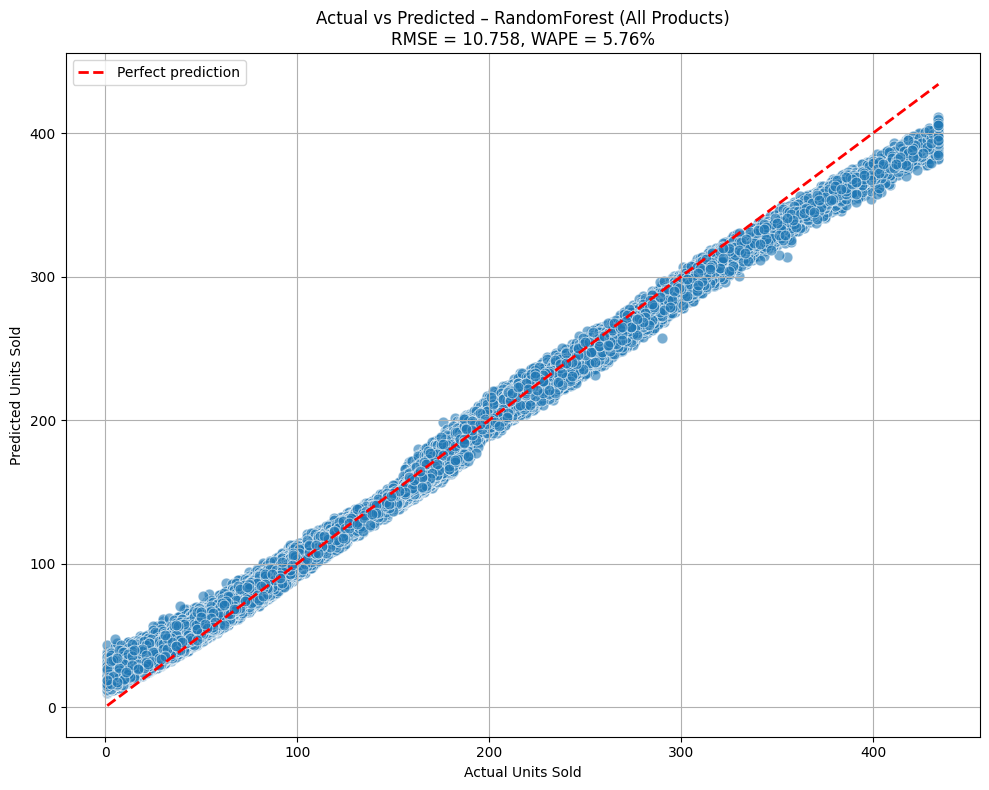

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ===============================
# 1. Fit preprocessor trên toàn bộ dữ liệu
# ===============================
X_all = df[numeric_features + categorical_features]
preprocessor.fit(X_all)  # Fit 1 lần cho toàn bộ

# ===============================
# 2. Tạo preds_product theo Product_ID
# ===============================
preds_product = {}

for pid, model in models_product.items():
    df_pid = df[df["Product_ID"] == pid].sort_values("Date").reset_index(drop=True)
    X_pid = preprocessor.transform(df_pid[numeric_features + categorical_features])
    y_actual = df_pid["Units_Sold"]
    y_pred = model.predict(X_pid)

    preds_product[pid] = pd.DataFrame({
        "Actual": y_actual,
        "Predicted": y_pred
    })

# ===============================
# 3. Gom tất cả Actual & Predicted
# ===============================
all_preds = []

for pid, df_pred in preds_product.items():
    df_tmp = df_pred.copy()
    df_tmp["Product_ID"] = pid
    all_preds.append(df_tmp)

all_preds = pd.concat(all_preds, axis=0).reset_index(drop=True)

# ===============================
# 4. Tính metric tổng toàn bộ Product_ID
# ===============================
actual_all = all_preds["Actual"].values
pred_all   = all_preds["Predicted"].values

# RMSE
total_rmse = np.sqrt(np.mean((actual_all - pred_all) ** 2))

# WAPE
non_zero = actual_all != 0
total_wape = (
    np.sum(np.abs(actual_all[non_zero] - pred_all[non_zero])) /
    np.sum(np.abs(actual_all[non_zero]))
) * 100

print(f"Toàn bộ Product_ID (sau train batch 5000, tổng dataset):")
print(f"RMSE = {total_rmse:.3f}, WAPE = {total_wape:.2f}%")

# ===============================
# 5. Plot Actual vs Predicted
# ===============================
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=all_preds,
    x="Actual",
    y="Predicted",
    alpha=0.6,
    s=60
)

min_val = min(all_preds["Actual"].min(), all_preds["Predicted"].min())
max_val = max(all_preds["Actual"].max(), all_preds["Predicted"].max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect prediction")

plt.title(
    f"Actual vs Predicted – RandomForest (All Products)\n"
    f"RMSE = {total_rmse:.3f}, WAPE = {total_wape:.2f}%"
)
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Calculating permutation importance for Product_ID=P0001
Calculating permutation importance for Product_ID=P0002
Calculating permutation importance for Product_ID=P0003
Calculating permutation importance for Product_ID=P0004
Calculating permutation importance for Product_ID=P0005
Calculating permutation importance for Product_ID=P0006
Calculating permutation importance for Product_ID=P0007
Calculating permutation importance for Product_ID=P0008
Calculating permutation importance for Product_ID=P0009
Calculating permutation importance for Product_ID=P0010
Calculating permutation importance for Product_ID=P0011
Calculating permutation importance for Product_ID=P0012
Calculating permutation importance for Product_ID=P0013
Calculating permutation importance for Product_ID=P0014
Calculating permutation importance for Product_ID=P0015
Calculating permutation importance for Product_ID=P0016
Calculating permutation importance for Product_ID=P0017
Calculating permutation importance for Product_I

,Importance_mean
Feature,
num__Demand_Forecast,1.066624
num__Inventory_Level,0.131718
num__roll_mean_7,0.005580
num__roll_std_28,0.005370
num__roll_std_7,0.005348
num__roll_std_14,0.005319
num__roll_mean_14,0.005287
num__roll_mean_28,0.005281
num__Competitor_Pricing,0.005215


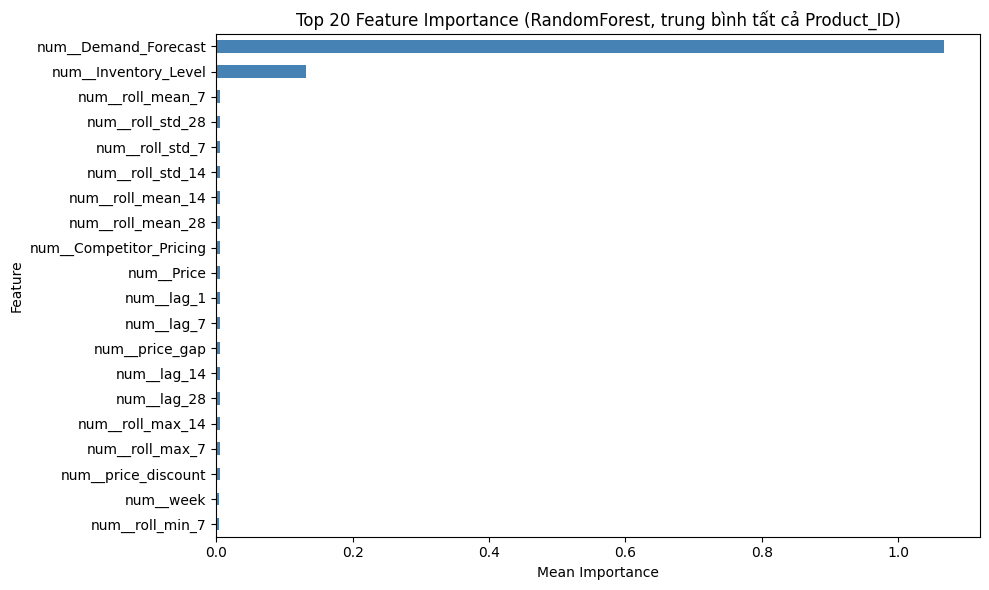

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ===============================
# 1. Load feature names từ preprocessor
# ===============================
feature_names = preprocessor.get_feature_names_out()

# ===============================
# 2. Tạo dict để lưu permutation importance
# ===============================
importances_dict = {}
all_importances = []

# ===============================
# 3. Loop qua từng Product_ID
# ===============================
for pid, model in models_product.items():
    print(f"Calculating permutation importance for Product_ID={pid}")

    df_pid = df[df["Product_ID"] == pid].sort_values("Date").reset_index(drop=True)
    X_pid = preprocessor.transform(df_pid[numeric_features + categorical_features])
    y_pid = df_pid["Units_Sold"]

    # Tính permutation importance
    r = permutation_importance(
        model,
        X_pid,
        y_pid,
        n_repeats=5,
        random_state=42,
        n_jobs=1  # để tránh quá tải RAM
    )

    imp_df = pd.DataFrame({
        "Product_ID": pid,
        "Feature": feature_names,
        "Importance_mean": r.importances_mean,
        "Importance_std": r.importances_std
    }).sort_values("Importance_mean", ascending=False)

    importances_dict[pid] = imp_df
    all_importances.append(imp_df)

# ===============================
# 4. Tổng hợp tất cả Product_ID
# ===============================
importances_all = pd.concat(all_importances, axis=0).reset_index(drop=True)

# Tính trung bình importance trên tất cả Product_ID
feature_avg_importance = (
    importances_all.groupby("Feature")["Importance_mean"]
    .mean()
    .sort_values(ascending=False)
)

# Lấy top 20 feature quan trọng nhất
top_features = feature_avg_importance.head(20)
print("\nTop 20 features trung bình trên tất cả Product_ID:")
display(top_features)

# ===============================
# 5. Vẽ biểu đồ feature importance
# ===============================
plt.figure(figsize=(10, 6))
feature_avg_importance.head(20).sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 20 Feature Importance (RandomForest, trung bình tất cả Product_ID)")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
# Lưu plot
plt.savefig("/content/drive/MyDrive/Colab Notebooks/plots(1)/feature_importance_avg_all_products.png", dpi=300)
plt.show()

print("Đã lưu plot feature importance trung bình tất cả Product_ID vào /content/drive/MyDrive/Colab Notebooks/plots(1)/")

<Figure size 640x480 with 0 Axes>

Đã lưu plot feature importance trung bình tất cả Product_ID vào /content/drive/MyDrive/Colab Notebooks/plots(1)/


In [ ]:
import joblib

for pid, model in models_product.items():
    # Lưu model
    joblib.dump(model, f"/content/drive/MyDrive/Colab Notebooks/models(1)/rf_{pid}.pkl")

    # Lưu dự đoán nếu tồn tại
    df_pred = preds_product.get(pid)
    if df_pred is not None:
        df_pred.to_csv(
            f"/content/drive/MyDrive/Colab Notebooks/preds(1)/rf_{pid}.csv",
            index=False
        )




In [ ]:
# LẤY FILE .HTML
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Raindom_Forest(PTDL)"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Raindom_Forest(PTDL) to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 680977 bytes to /content/drive/MyDrive/Colab Notebooks/Raindom_Forest(PTDL.html
